In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/FS_Attack-main

/content/drive/MyDrive/FS_Attack-main


In [ ]:
pip install saliency

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 3.5 MB/s eta 0:00:00


In [ ]:
import argparse
import torch
import torchvision
import torch.nn.functional as F
import numpy as np
import json

from nn.enums import ExplainingMethod
from nn.networks import ExplainableNet
from nn.utils import get_expl, plot_overview, clamp, load_image, make_dir
from nn.utils import gini_tensor, load_numpy, load_image_nopreprocess, show_expl
from nn.utils import gini_numpy, gini_tensor2, gini_tensor_ori, gini_tensor_double
from nn.utils import torch_to_image_ver2, png_to_jpeg, heatmap_to_image
from nn.utils import get_center_attack_matrix, show_expl_title, topk_intersection, show_expl_title_return_im
import samples.samples as DS
from models.mytool import * # 切換 model 的 function 跟 get_beta  #Switch model function and get_beta
import re #正規表達式 lib # regular expression
from nn.imagetool import * # 印各種圖片(灰階 熱點) #Print various pictures grayscale
import saliency.core as saliency
from PIL import Image
from matplotlib import pylab as P
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio
#from skimage.measure import compare_ssim
from skimage.metrics import structural_similarity as ssim

from scipy.stats import pearsonr
torch.set_printoptions(precision=7) # tensor 小數點後7位
%matplotlib inline
#要加這一行才有辦法直接用 imshow印出圖片 且只要加一次 所以加在最前面
# Only by adding this line can we directly use imshow to print the picture.
# And it only needs to be added once, so it is added at the front.

no display found. Using non-interactive Agg backend


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]
100%|██████████| 170M/170M [00:03<00:00, 46.6MB/s]


### 基本設定
### Basic Configuration

In [ ]:
#from mytool import set_parameter_requires_grad
#DATASET = 'imagenet'
DATASET = 'cifar10'
MODEL = 'VGG16' # ['RESNET50','_DENSENET121','VGG16','INCEPTIONV3','MOBILENETV2']
img_number = 100
size = 32 #224 #299 # 改變圖片大小 cifar10 原本是32x32
#""""""""""""""""""""""""""""""""""
# resnet 224
# alexnet 224
# vgg 224
# squeezenet 224
# mobilenet 224
# densenet 224
# inception 299
#""""""""""""""""""""""""""""""""""
#config_path = '/tf/XAI_Attack/config/model_config.json'
config_path = '/content/drive/MyDrive/FS_Attack-main/config/model_config.json'
#config_path = '/content/drive/MyDrive/Colab Notebooks/FS_Attack-main/config/model_config.json'
config = json.load(open(config_path))['{}_{}_{}'.format('torch', MODEL, DATASET)]
#label_dict = getattr(dataset_label, DATASET)
#model_types = re.findall("^([a-z]+)", config['model'])[0]
nb_classes = config['label']
# model_tsai = TORCH_MODEL(model_name = MODEL, dataset = DATASET, gpu = torch.cuda.is_available())
ds = getattr(DS, DATASET)
print('ds type: ',type(ds))
print('ds[0] type: ',type(ds[0]),ds[0])
indices = torch.randperm(len(ds.targets))[:img_number].numpy().astype(int) #隨機抽 img_number 張圖
images_list, labels = [np.array(ds[i][0].resize((size,size)).convert('RGB')) for i in indices], [np.array(ds[i][1]) for i in indices]
print('images_list type:',type(images_list))
images_arr, labels = np.array(images_list).astype('float32'), np.array(labels)
print('images_arr type:',type(images_arr),images_arr.shape)
labels_torch = torch.from_numpy(labels)

images = torch.tensor(images_arr)
print('images:',type(images),images.shape)
print('labels:',labels.shape)
print('model:',MODEL)
print('dataset:',DATASET)

ds type:  <class 'torchvision.datasets.cifar.CIFAR10'>
ds[0] type:  <class 'tuple'> (<PIL.Image.Image image mode=RGB size=32x32 at 0x78826FBEE410>, 3)
images_list type: <class 'list'>
images_arr type: <class 'numpy.ndarray'> (100, 32, 32, 3)
images: <class 'torch.Tensor'> torch.Size([100, 32, 32, 3])
labels: (100,)
model: VGG16
dataset: cifar10


In [ ]:
print(images.shape)

torch.Size([100, 32, 32, 3])


### 讀取圖片 Read Pictures

In [ ]:
!pip install opencv-python


In [ ]:
import cv2
img = 'tmp_image/'+'11'+'.jpeg'
img = cv2.imread(img)
print(img.shape)

(224, 224, 3)


In [ ]:
from torchvision import transforms
from PIL import Image

# Define the preprocessing transformation
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# Load and preprocess the image directly with PIL
img_path = 'tmp_image/11.jpeg'  # Adjust the path if needed
img = Image.open(img_path).convert('RGB')  # Ensure it's RGB mode

# Apply the preprocessing transformations
img_tensor = preprocess(img).unsqueeze(0)


In [ ]:
print(img_tensor.shape)

torch.Size([1, 3, 224, 224])


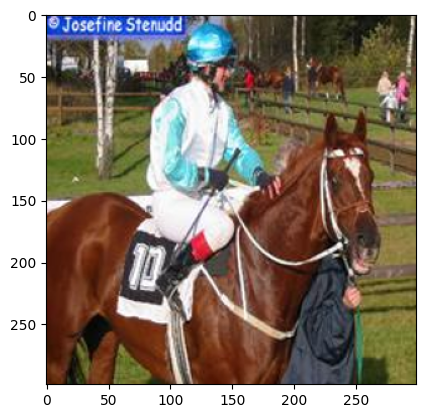

In [ ]:
num_iter = 150
#img = 'data/collie4.jpeg' #要攻擊的圖
#img = 'good_images/example_627_ver2/x.jpeg'
case = '11'
exp_method = 'lrp' #  choices=['lrp', 'guided_backprop', 'gradient', 'integrated_grad', 'pattern_attribution', 'grad_times_input']
#img = 'tmp_image/'+case+'.jpeg'
img = 'tmp_image/'+case+'.jpeg'
#img = 'temp_result/case_'+case+'.jpeg'

red = 'nn/RED.jpeg'
lr = 0.0002
cuda = True
output_dir = 'temp_result/'
beta_growth = True
prefactors = [1e4, 1e10, 1e-4] # 4 10 -4
device = torch.device("cuda" if cuda else "cpu")
#device = "cpu"
method = getattr(ExplainingMethod, exp_method)
# 確認實驗的圖片
im_orig = LoadImage(img)
P.imshow(im_orig)

In [ ]:
print(im_orig.shape)

(299, 299, 3)


### 讀取model

In [ ]:
from torchvision.models import VGG16_Weights

In [ ]:
# load model
data_mean = np.array([0.485, 0.456, 0.406])
data_std = np.array([0.229, 0.224, 0.225])
#model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
vgg_model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

#vgg_model = torchvision.models.vgg16(pretrained=True)
#vgg_model = torchvision.models.alexnet(pretrained=True)
model = ExplainableNet(vgg_model, data_mean=data_mean, data_std=data_std, beta=1000 if beta_growth else None)
#if method == ExplainingMethod.pattern_attribution:
#    model.load_state_dict(torch.load('../models/model_vgg16_pattern_small.pth'), strict=False)
model = model.eval().to(device)


#x_target = load_image(data_mean, data_std, device, target_img)


# load images
x = load_image(data_mean, data_std, device, img)
#x = load_image_nopreprocess(data_mean, data_std, device, img)


x_adv = x.clone().detach().requires_grad_()
print('x',x.shape,type(x))
print('x range',x.min(),x.max())
print('x_adv',x_adv.shape,type(x_adv))
print('x_adv range',x_adv.min(),x_adv.max())

# produce expls
org_expl, org_acc, org_idx = get_expl(model, x, method)
org_expl = org_expl.detach().cpu()
#target_expl, _, _ = get_expl(model, x_target, method)
#target_expl = target_expl.detach()

print(org_expl)

# target attack
target_mtx = get_center_attack_matrix(200, 200, 35, org_expl, 224)
target_mtx_torch = torch.tensor(target_mtx)
target_mtx_torch = target_mtx_torch.view(1,224,224)
target_mtx_torch = target_mtx_torch.to(device)
target_mtx_torch = target_mtx_torch.float()

optimizer = torch.optim.Adam([x_adv], lr=lr)


x torch.Size([1, 3, 224, 224]) <class 'torch.Tensor'>
x range tensor(-2.1007793, device='cuda:0') tensor(2.6400001, device='cuda:0')
x_adv torch.Size([1, 3, 224, 224]) <class 'torch.Tensor'>
x_adv range tensor(-2.1007793, device='cuda:0', grad_fn=<MinBackward1>) tensor(2.6400001, device='cuda:0', grad_fn=<MaxBackward1>)
tensor([[[1.0694229e-05, 1.4489391e-05, 1.3932943e-05,  ...,
          1.3500983e-05, 2.3982189e-05, 1.6494729e-05],
         [1.5770040e-05, 2.1072517e-05, 2.0960319e-05,  ...,
          1.7892997e-05, 2.6742831e-05, 1.6881109e-05],
         [1.5019376e-05, 1.8656374e-05, 1.9154888e-05,  ...,
          9.6902450e-06, 1.4497600e-05, 1.4469517e-05],
         ...,
         [2.2834405e-05, 4.2605909e-05, 3.6500216e-05,  ...,
          2.7620454e-05, 2.6583311e-05, 1.6279020e-05],
         [2.6845006e-05, 5.8626167e-05, 7.0390539e-05,  ...,
          2.9295490e-05, 2.8235421e-05, 1.7301554e-05],
         [1.7376386e-05, 3.8405768e-05, 4.2239517e-05,  ...,
          1.830977

In [ ]:
print(target_mtx_torch.shape)
print(org_expl.shape)
print(img_tensor.shape)

torch.Size([1, 224, 224])
torch.Size([1, 224, 224])
torch.Size([1, 3, 224, 224])


### 先用實驗模型預測單張樣本
First use the experimental model to predict a single sample

im2.shape:  (224, 224, 3)
im_orig: (224, 224, 3) <class 'numpy.ndarray'>
im_tensor torch.Size([1, 3, 224, 224]) <class 'torch.Tensor'>
im_tensor range tensor(-2.1179039, grad_fn=<MinBackward1>) tensor(2.6400001, grad_fn=<MaxBackward1>)


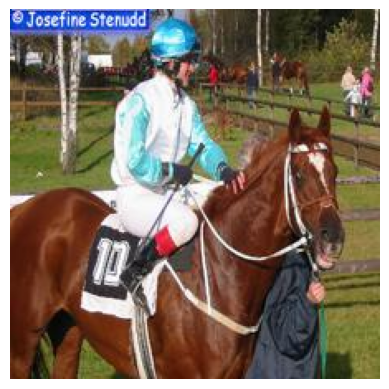

In [ ]:

im = Image.open(img)
im2 = np.array(im)
im2 = im2.astype(np.float64)
im_orig = im2 #  (224,224,3) 而且這裡的是小數化的整數表示，沒有經過data_mean跟data_sta前處理的 #Moreover, what is represented here is a decimalized integer representation, which has not been pre-processed by data_mean and data_sta.
print('im2.shape: ',im2.shape)
im_tensor = PreprocessImages([im_orig])
# Show the image
im_orig_int = np.int_(im_orig) #要從float轉成int才有辦法用ShowImage印出來 #You need to convert from float to int before you can print it out using ShowImage.
ShowImage(im_orig_int)
print('im_orig:',im_orig.shape, type(im_orig)) # im_orig:  (299, 299, 3) <class 'numpy.ndarray'>
print('im_tensor',im_tensor.shape,type(im_tensor))
print('im_tensor range',im_tensor.min(),im_tensor.max())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
im_tensor = im_tensor.to(device)


In [ ]:
predictions = model(im_tensor)
predictions = predictions.cpu().detach().numpy()
prediction_class = np.argmax(predictions[0])

print("Prediction class: " + str(prediction_class))  # Should be a doberman, class idx = 236
origin_prediction_class = prediction_class
im = im_orig.astype(np.float32)
print('im: ',im.shape, type(im)) # im:  (299, 299, 3) <class 'numpy.ndarray'>
print('ori_image')
value_sort = np.sort(predictions[0])[::-1]
print(value_sort[:2][0], value_sort[:2][1])
score_diff = value_sort[:2][0] - value_sort[:2][1]
print('dump score diff:',score_diff)

Prediction class: 339
im:  (224, 224, 3) <class 'numpy.ndarray'>
ori_image
25.732843 18.80044
dump score diff: 6.9324036


In [ ]:
value_sort = np.sort(predictions[0])[::-1]
index_sort = np.argsort(predictions[0])[::-1]
for i in range(5):
    print('label: ',index_sort[:5][i], ' score: ',value_sort[:5][i])

label:  339  score:  25.732843
label:  603  score:  18.80044
label:  912  score:  17.011047
label:  427  score:  15.770437
label:  756  score:  15.04903


### 攻擊開始
### Attack begins

Experimenting 2 cell

In [ ]:
adv_expl, adv_acc, class_idx = get_expl(model, x_adv, method, desired_index=org_idx)
#print('adv_expl',adv_expl)
#print('adv_acc',adv_acc)
#print('class_index',class_idx)

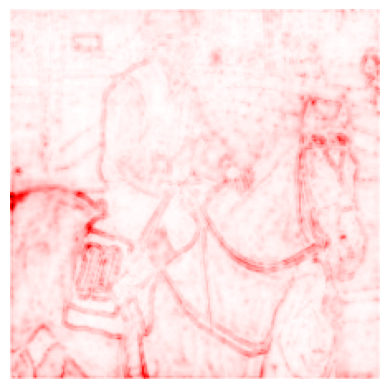

In [ ]:
show_expl_title(org_expl, cm = 'seismic')
# autumn, bone, cool, copper, flag, gray, hot, hsv, inferno,
# jet, magma, pink, plasma, prism, spring, summer, viridis, winter,
#im_adv = show_expl_title_return_im(adv_expl, cm='seismic')


In [ ]:
#import os
#os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


Iteration 1: Total Loss: 1128.572998046875, Gini Loss: 1.1285700196594917e-07, Output Loss: 2.934248186647892e-07
Iteration 49: Total Loss: 1118.7176513671875, Gini Loss: 1.1185655068857159e-07, Output Loss: 1.5205285308184102e-05
Iteration 99: Total Loss: 1107.85400390625, Gini Loss: 1.107608298411833e-07, Output Loss: 2.4569095330662094e-05
Iteration 149: Total Loss: 1100.94873046875, Gini Loss: 1.100664235309523e-07, Output Loss: 2.844985829142388e-05


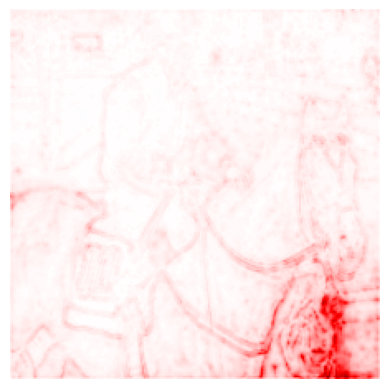

In [ ]:
total_loss_list = []
epoch_exp = []
L1_score = []
L2_score = []
L3_score = []
L4_score = []
L5_score = []

early_stop_epoch = 0
mode_2_loss = False
EARLY_STOP = True #False
for i in range(num_iter):
    if beta_growth:
        model.change_beta(get_beta(i, num_iter))

    optimizer.zero_grad()

    # calculate loss
    adv_expl, adv_acc, class_idx = get_expl(model, x_adv, method, desired_index=org_idx)

    loss_center = F.mse_loss(adv_expl, target_mtx_torch)
    loss_output = F.mse_loss(adv_acc[0][prediction_class], org_acc[0][prediction_class].detach())
    #loss_output = F.mse_loss(adv_acc, org_acc.detach())
    if mode_2_loss:
        total_loss = prefactors[0]*loss_output + prefactors[1]*loss_center
    else:
        total_loss = prefactors[0]*loss_output + prefactors[1]*loss_center

    total_loss_list.append(total_loss.item())
    x_tmp = x_adv
    # update adversarial example
    total_loss.backward()
    optimizer.step()
    predictions = model(x_adv)
    predictions = predictions.cpu().detach().numpy()
    if (value_sort[:2][0] - value_sort[:2][1]) < 1 :
        mode_2_loss = True
    #print(i,predictions[0][prediction_class], value_sort[:2][0], value_sort[:2][1])
    L1_score.append(predictions[0][index_sort[:5][0]])
    L2_score.append(predictions[0][index_sort[:5][1]])
    L3_score.append(predictions[0][index_sort[:5][2]])
    L4_score.append(predictions[0][index_sort[:5][3]])
    L5_score.append(predictions[0][index_sort[:5][4]])
    prediction_class_tmp = np.argmax(predictions[0])
    if(prediction_class != prediction_class_tmp):
        print(i,'early done')
        early_stop_epoch = i
        if EARLY_STOP == True:
            x_adv = x_tmp
            break

    x_adv.data = clamp(x_adv.data, data_mean, data_std)
    if i == 1:
        print("Iteration {}: Total Loss: {}, Gini Loss: {}, Output Loss: {}".format(i, total_loss.item(), loss_center.item(), loss_output.item()))
    #print("Iteration {}: Total Loss: {}, Expl Loss: {}, Output Loss: {}".format(i, total_loss.item(), loss_expl.item(), loss_output.item()))

    if (i+1)%50 == 0:
        print("Iteration {}: Total Loss: {}, Gini Loss: {}, Output Loss: {}".format(i, total_loss.item(), loss_center.item(), loss_output.item()))
        show_expl_title(adv_expl, cm = 'seismic')
        im_adv = show_expl_title_return_im(adv_expl, cm='seismic')
        epoch_exp.append(adv_expl)




# Computing Metrics

In [ ]:
# value_sort = np.sort(predictions[0])[::-1]
# index_sort = np.argsort(predictions[0])[::-1]
# for i in range(5):
#     print('label: ',index_sort[:5][i], ' score: ',value_sort[:5][i])

### 原始解釋圖
### original explanation diagram

In [ ]:
# # 目前解釋圖只有辦法存原論文的OAO #Currently, the only way to save explanation figures is in the OAO of the original paper.
# # 原始解釋圖
# show_expl_title(org_expl, cm= 'seismic')
# im_ori = show_expl_title_return_im(org_expl, cm='seismic')
# print('ori_exp')

### 擾動解釋圖
### Disturbance explanation diagram

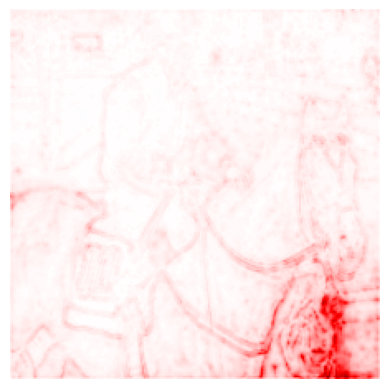

In [ ]:
# # 擾動解釋圖 #Disturbance explanation diagram
show_expl_title(adv_expl, cm = 'seismic')
# # autumn, bone, cool, copper, flag, gray, hot, hsv, inferno,
# # jet, magma, pink, plasma, prism, spring, summer, viridis, winter,
# im_adv = show_expl_title_return_im(adv_expl, cm='seismic')

# print('adv_expl')

Visualization of Original Image

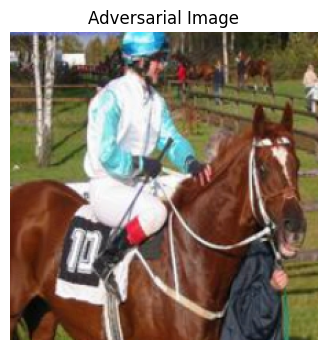

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms as T

# Unnormalize the adversarial image (assumes clamp used data_mean/data_std)
def unnormalize(img_tensor, mean, std):
    for t, m, s in zip(img_tensor, mean, std):
        t.mul_(s).add_(m)
    return img_tensor

# Clone and unnormalize for visualization
adv_img = x_adv.detach().cpu().squeeze().clone()
adv_img = unnormalize(adv_img, data_mean, data_std)
adv_img = adv_img.permute(1, 2, 0).numpy()  # CHW to HWC for matplotlib

# Clip values to [0, 1] just in case
adv_img = np.clip(adv_img, 0, 1)

# Plot the adversarial image
plt.figure(figsize=(4, 4))
plt.imshow(adv_img)
plt.title("Adversarial Image")
plt.axis('off')
plt.show()


### Metric

Original Explanation and Adversarial Explanation Computing metrics

In [ ]:
adv_expl_np = adv_expl[0].cpu().detach().numpy()
org_expl_np = org_expl[0].cpu().detach().numpy()
# Assuming adv_expl_np and org_expl_np are numpy arrays with values between 0 and 1
ssim_value = structural_similarity(adv_expl_np, org_expl_np, multichannel=True, data_range=adv_expl_np.max() - adv_expl_np.min())
print('ssim')
print('ori and adv :', ssim_value)
#print('ori and mal :', structural_similarity(org_expl_np, target_mtx, multichannel=True, data_range=adv_expl_np.max() - adv_expl_np.min()))
#print('adv and mal :', structural_similarity(adv_expl_np, target_mtx, multichannel=True, data_range=adv_expl_np.max() - adv_expl_np.min()))



ssim
ori and adv : 0.8013024297804292


In [ ]:
# print('mse')
print('ori and adv :', mean_squared_error(adv_expl_np, org_expl_np))

ori and adv : 8.601963574556657e-10


FSD

With Pre-trained ResNet-50

In [ ]:
#Load pretrained model
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# # Load pretrained model
# model = models.vgg16(pretrained=True)

In [ ]:
device = x_adv.device
model = model.to(device)
pred = model(x_adv).argmax(1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.autograd import Variable

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.autograd import Variable

class FocusShiftDefense:
    def __init__(self, model, epsilon=0.1):
        """
        Args:
            model: Pretrained model (e.g., ResNet, VGG)
            epsilon: Hyperparameter controlling feature enhancement strength
        """
        self.model = model
        self.epsilon = epsilon
        self.model.eval()  # Set to evaluation mode

        # Register hook to get last conv layer activations
        self.activations = None
        self._register_hook()

    def _register_hook(self):
        """Hook to capture activations from last conv layer"""
        def hook(module, input, output):
            self.activations = output

        # Find last convolutional layer dynamically
        last_conv = None
        for layer in self.model.modules():
            if isinstance(layer, nn.Conv2d):
                last_conv = layer
        if last_conv is None:
            raise ValueError("No convolutional layer found in model")

        last_conv.register_forward_hook(hook)

    def defend(self, x_adv, target_label):
        """
        Enhance important features to counter focus-shifting

        Args:
            x_adv: Adversarial image (tensor) [1,C,H,W]
            target_label: Original predicted label

        Returns:
            Defended image tensor
        """
        # Forward pass to get activations
        with torch.no_grad():
            _ = self.model(x_adv)

        if self.activations is None:
            raise RuntimeError("No activations captured")

        # Get top-k important activation channels for target class
        A = self.activations  # [1, C, H, W]
        C = A.shape[1]

        # Global average pooling to find important channels
        gap = F.adaptive_avg_pool2d(A, (1, 1)).squeeze()  # [C]
        important_channels = torch.topk(gap, k=C//4).indices  # Top 25% channels

        # Create enhancement mask
        enhancement_mask = torch.zeros_like(A)
        for c in important_channels:
            enhancement_mask[:, c, :, :] = 1  # Only enhance important channels

        # Apply enhancement: x' + ε*A⊙M
        #x_defended = x_adv + self.epsilon * (A * enhancement_mask)
        #x_defended = x_adv + self.epsilon * nn.functional.interpolate((A * enhancement_mask), size=x_adv.shape[2:], mode='bilinear', align_corners=False)
        x_defended = x_adv + self.epsilon * nn.functional.conv2d(nn.functional.interpolate(A * enhancement_mask, size=x_adv.shape[2:], mode='bilinear', align_corners=False),
    weight=torch.ones(3, A.shape[1], 1, 1, device=x_adv.device))  # Project 2048 channels → 3

        # Clip to valid image range
        x_defended = torch.clamp(x_defended, 0, 1)

        return x_defended


In [ ]:
 # Initialize defense
defense = FocusShiftDefense(model, epsilon=0.15)

In [ ]:
# Apply defense
x_defended = defense.defend(x_adv, pred)

Visualization of x_defended

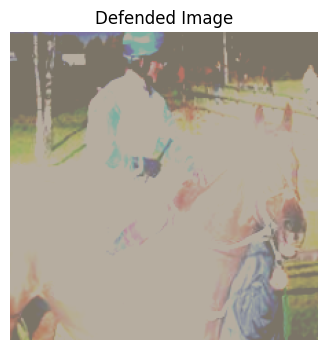

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms as T

# Unnormalize the adversarial image (assumes clamp used data_mean/data_std)
def unnormalize(img_tensor, mean, std):
    for t, m, s in zip(img_tensor, mean, std):
        t.mul_(s).add_(m)
    return img_tensor

# Clone and unnormalize for visualization
def_img = x_defended.detach().cpu().squeeze().clone()
def_img = unnormalize(def_img, data_mean, data_std)
def_img = def_img.permute(1, 2, 0).numpy()  # CHW to HWC for matplotlib

# Clip values to [0, 1] just in case
#def_img = np.clip(def_img, 0, 1)

# Plot the adversarial image
plt.figure(figsize=(4, 4))
plt.imshow(def_img)
plt.title("Defended Image")
plt.axis('off')
plt.show()


In [ ]:
x_defended = x_defended.clone().detach().requires_grad_(True)

In [ ]:
# load model
data_mean = np.array([0.485, 0.456, 0.406])
data_std = np.array([0.229, 0.224, 0.225])
#model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
vgg_model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

#vgg_model = torchvision.models.vgg16(pretrained=True)
#vgg_model = torchvision.models.alexnet(pretrained=True)
model = ExplainableNet(vgg_model, data_mean=data_mean, data_std=data_std, beta=1000 if beta_growth else None)
#if method == ExplainingMethod.pattern_attribution:
#    model.load_state_dict(torch.load('../models/model_vgg16_pattern_small.pth'), strict=False)
model = model.eval().to(device)


In [ ]:
# execute VGG-16 MODEL PART
def_expl, def_acc, class_idx = get_expl(model, x_defended, method, desired_index=org_idx)


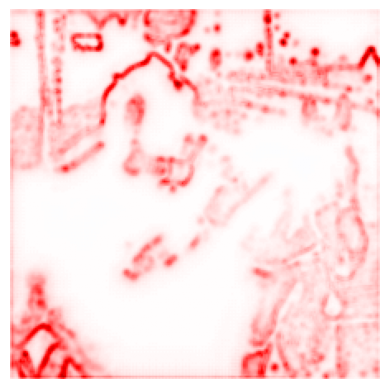

In [ ]:
# # 擾動解釋圖 #Disturbance explanation diagram
show_expl_title(def_expl, cm = 'seismic')
# # autumn, bone, cool, copper, flag, gray, hot, hsv, inferno,
# # jet, magma, pink, plasma, prism, spring, summer, viridis, winter,
# im_adv = show_expl_title_return_im(adv_expl, cm='seismic')

# print('adv_expl')

Evaluation Metrics